# Gradient Boosting (Regression) 

## Step 1: Given Dataset

| IQ  | CGPA | Salary (y) |
|-----|------|-----------|
| 90  | 8    | 3         |
| 100 | 7    | 4         |
| 110 | 6    | 8         |
| 120 | 9    | 6         |
| 80  | 5    | 3         |

---

## Step 2: Model 1 (Base Model)

The first model is a constant model.  
It predicts the mean of the target variable (Salary).

### Mean Calculation:
$$
\text{Mean} = \frac{3 + 4 + 8 + 6 + 3}{5} = 4.8
$$

---

## Step 3: Predictions from Model 1

| IQ  | CGPA | Salary (y) | Pred₁ |
|-----|------|-----------|-------|
| 90  | 8    | 3         | 4.8   |
| 100 | 7    | 4         | 4.8   |
| 110 | 6    | 8         | 4.8   |
| 120 | 9    | 6         | 4.8   |
| 80  | 5    | 3         | 4.8   |

---

## Step 4: Compute Residuals (Errors)

Residual is calculated as:

\[
\text{Residual} = y - \hat{y}
\]

| IQ  | CGPA | Salary (y) | Pred₁ | Residual (res₁) |
|-----|------|-----------|-------|----------------|
| 90  | 8    | 3         | 4.8   | -1.8           |
| 100 | 7    | 4         | 4.8   | -0.8           |
| 110 | 6    | 8         | 4.8   | 3.2            |
| 120 | 9    | 6         | 4.8   | 1.2            |
| 80  | 5    | 3         | 4.8   | -1.8           |

These residuals represent the errors made by Model 1.

---

## Step 5: Model 2 (Learning from Mistakes)

We now train Model 2 using a Decision Tree.

### Inputs:
- IQ
- CGPA

### Target:
- Residuals (res₁)

Model 2 learns to predict the errors made by Model 1.

---

## Key Insight

Model 2 does not predict the original target (Salary).  
It predicts how much Model 1 was wrong.

---

## Intuition

- Model 1 provides an initial rough prediction (mean)
- Model 2 learns the corrections (residuals)
- Future predictions will combine both models

$$
\text{Final Prediction} = \text{Model 1} + \text{Model 2}
$$

---

## 

Gradient Boosting works by:
- Starting with a simple model
- Iteratively adding models that correct previous errors

In [1]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

In [2]:
data = {
    "IQ": [90, 100, 110, 120, 80],
    "CGPA": [8, 7, 6, 9, 5],
    "Salary": [3, 4, 8, 6, 3]
}

df = pd.DataFrame(data)

In [3]:
X = df[["IQ", "CGPA"]]
y = df["Salary"]

In [4]:
y_mean = y.mean()
df["Pred1"] = y_mean

In [5]:
df["res1"] = df["Salary"] - df["Pred1"]

print("Dataset with predictions and residuals:\n")
print(df)

Dataset with predictions and residuals:

    IQ  CGPA  Salary  Pred1  res1
0   90     8       3    4.8  -1.8
1  100     7       4    4.8  -0.8
2  110     6       8    4.8   3.2
3  120     9       6    4.8   1.2
4   80     5       3    4.8  -1.8


In [7]:
model2 = DecisionTreeRegressor(max_depth=2)
model2.fit(X, df["res1"])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

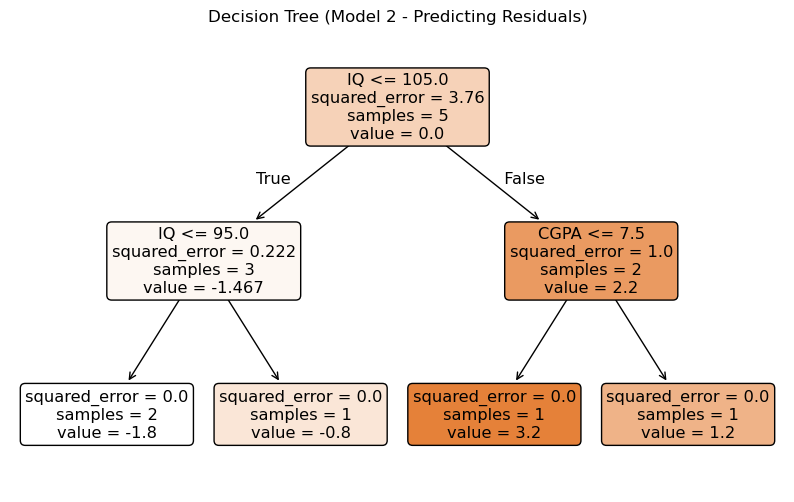

In [8]:
plt.figure(figsize=(10, 6))
plot_tree(
    model2,
    feature_names=["IQ", "CGPA"],
    filled=True,
    rounded=True
)
plt.title("Decision Tree (Model 2 - Predicting Residuals)")
plt.show()

#### Predictions from Model 2

Model 2 is trained on residuals (res₁).  
Now we generate predictions from Model 2.

| IQ  | CGPA | res₁ | Pred₂ |
|-----|------|------|-------|
| 90  | 8    | -1.8 | -1.8  |
| 100 | 7    | -0.8 | -0.8  |
| 110 | 6    | 3.2  | 3.2   |
| 120 | 9    | 1.2  | 1.2   |
| 80  | 5    | -1.8 | -1.8  |

Note: In this simplified case, Pred₂ ≈ res₁ because the tree fits perfectly.

---

#### Final Prediction (2 Models)

If we are using only 2 models:

$$
\text{Final Prediction} = \text{Pred₁} + \text{Pred₂}
$$

---

#### Final Results Table

| IQ  | CGPA | Salary (y) | Pred₁ | Pred₂ | Final Prediction |
|-----|------|-----------|-------|-------|------------------|
| 90  | 8    | 3         | 4.8   | -1.8  | 3.0              |
| 100 | 7    | 4         | 4.8   | -0.8  | 4.0              |
| 110 | 6    | 8         | 4.8   | 3.2   | 8.0              |
| 120 | 9    | 6         | 4.8   | 1.2   | 6.0              |
| 80  | 5    | 3         | 4.8   | -1.8  | 3.0              |

---

> # here this is overfitting actually !

In practice, we use a learning rate:

$$
\text{Final Prediction} = \text{Pred₁} + \eta \cdot \text{Pred₂}
$$

where:
- $$\eta$$ = learning rate (e.g., 0.1)

This prevents overfitting and makes learning gradual.

##  Construct New Column

We create a new column:

**Final_Pred_LR = Pred₁ + η × Pred₂**

---

## Updated Table

| IQ  | CGPA | Salary (y) | Pred₁ | Pred₂ | Final_Pred_LR |
|-----|------|-----------|-------|-------|----------------|
| 90  | 8    | 3         | 4.8   | -1.8  | 4.62           |
| 100 | 7    | 4         | 4.8   | -0.8  | 4.72           |
| 110 | 6    | 8         | 4.8   | 3.2   | 5.12           |
| 120 | 9    | 6         | 4.8   | 1.2   | 4.92           |
| 80  | 5    | 3         | 4.8   | -1.8  | 4.62           |

---


## Table

| Pred₁ | res₁ | Pred₂ | res₂  |
|-------|------|-------|-------|
| 4.8   | -1.8 | -1.8  | -1.62 |
| 4.8   | -0.8 | -0.8  | -0.72 |
| 4.8   | 3.2  | 3.2   | 2.88  |
| 4.8   | 1.2  | 1.2   | 1.08  |
| 4.8   | -1.8 | -1.8  | -1.62 |

> in ideal case : residual should be zero , and here we can see its moving towards zero 

## Model 3 (Learning from res₂)

For Model 3, we again use the same input features:

- Input: ["IQ", "CGPA"]  
- Target: res₂  

---

## Training Data for Model 3

| IQ  | CGPA | res₂  |
|-----|------|-------|
| 90  | 8    | -1.62 |
| 100 | 7    | -0.72 |
| 110 | 6    | 2.88  |
| 120 | 9    | 1.08  |
| 80  | 5    | -1.62 |

---

## Model 3 Prediction

Train a Decision Tree:

- Model 3 learns patterns in res₂  
- Output column = Pred₃  

In ideal case (perfect fit):

| IQ  | CGPA | res₂  | Pred₃ |
|-----|------|-------|-------|
| 90  | 8    | -1.62 | -1.62 |
| 100 | 7    | -0.72 | -0.72 |
| 110 | 6    | 2.88  | 2.88  |
| 120 | 9    | 1.08  | 1.08  |
| 80  | 5    | -1.62 | -1.62 |

---

## Updated Prediction (3 Models)

$$
F(x) = \text{Pred₁} + \eta \cdot \text{Pred₂} + \eta \cdot \text{Pred₃}
$$

---

## New Residuals

$$
\text{res₃} = y - F(x)
$$

---

## Key Insight

- Each model learns from previous errors  
- Errors keep shrinking:  
  $$|res₁| > |res₂| > |res₃|$$  
- This is why Gradient Boosting is powerful  

---

| y | Pred₁ | Pred₂ | Pred₃ | F(x) = 4.8 + 0.1·Pred₂ + 0.1·Pred₃ | res₃   |
| - | ----- | ----- | ----- | ---------------------------------- | ------ |
| 3 | 4.8   | -1.8  | -1.62 | 4.8 - 0.18 - 0.162 = 4.458         | -1.458 |
| 4 | 4.8   | -0.8  | -0.72 | 4.8 - 0.08 - 0.072 = 4.648         | -0.648 |
| 8 | 4.8   | 3.2   | 2.88  | 4.8 + 0.32 + 0.288 = 5.408         | 2.592  |
| 6 | 4.8   | 1.2   | 1.08  | 4.8 + 0.12 + 0.108 = 5.028         | 0.972  |
| 3 | 4.8   | -1.8  | -1.62 | 4.458   .........                  | -1.458 |


## Final Output (with 3 Models)

We use:

$$
F(x) = \text{Pred₁} + \eta \cdot \text{Pred₂} + \eta \cdot \text{Pred₃}
$$

where:
- Pred₁ = 4.8  
- Pred₂ = res₁  
- Pred₃ = res₂  
- $$\eta = 0.1$$  

---

## Final Predictions

| IQ  | CGPA | Final Output F(x) |
|-----|------|-------------------|
| 90  | 8    | 4.458             |
| 100 | 7    | 4.648             |
| 110 | 6    | 5.408             |
| 120 | 9    | 5.028             |
| 80  | 5    | 4.458             |

---

## Compact Form

$$
F(x) = 4.8 + 0.1 \cdot res₁ + 0.1 \cdot res₂
$$

---

## Key Insight

- Model 1 → baseline (mean = 4.8)  
- Model 2 → first correction  
- Model 3 → second correction  
- Final output = sum of all corrections (scaled)

---

## Important Observation

- Predictions move closer to actual values step-by-step  
- Learning is gradual due to learning rate  
- More models → better approximation

----------

-------------

# Gradient Boosting (Manual — till 3 models)

In [12]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

In [14]:
np.random.seed(42)

n = 100

IQ = np.random.randint(80, 140, n)
CGPA = np.random.uniform(5, 10, n)

In [15]:
Salary = 0.05 * IQ + 1.5 * CGPA + np.random.normal(0, 2, n)

df = pd.DataFrame({
    "IQ": IQ,
    "CGPA": CGPA,
    "Salary": Salary
})

In [16]:
X = df[["IQ", "CGPA"]]
y = df["Salary"]

In [17]:
df["pred1"] = y.mean()

In [18]:
df["res1"] = y - df["pred1"]

In [28]:
model2 = DecisionTreeRegressor(max_depth=3)
model2.fit(X, df["res1"])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [29]:
df["pred2"] = model2.predict(X)

In [30]:
lr = 0.1

In [31]:
df["res2"] = y - (df["pred1"] + lr * df["pred2"])

In [32]:
model3 = DecisionTreeRegressor(max_depth=3)
model3.fit(X, df["res2"])

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [33]:
df["pred3"] = model3.predict(X)

In [34]:
df["final_pred"] = df["pred1"] + lr * df["pred2"] + lr * df["pred3"]

In [35]:
df["res3"] = y - df["final_pred"]

In [36]:
df.head()

,IQ,CGPA,Salary,pred1,res1,pred2,res2,pred3,final_pred,res3
0,118,7.852220,17.249681,16.480662,0.769019,0.800923,0.688927,0.720831,16.632837,0.616844
1,131,7.604171,16.577869,16.480662,0.097207,-0.322743,0.129481,-0.290468,16.419341,0.158528
2,108,9.805860,21.564456,16.480662,5.083795,3.719343,4.711860,4.120554,17.264651,4.299805
3,94,9.222669,17.295865,16.480662,0.815203,0.800923,0.735111,0.720831,16.632837,0.663028
4,122,8.736601,19.917220,16.480662,3.436559,2.590389,3.177520,2.331350,16.972836,2.944385


In [37]:
from sklearn.metrics import mean_squared_error

mse1 = mean_squared_error(y, df["pred1"])
mse2 = mean_squared_error(y, df["pred1"] + 0.1 * df["pred2"])
mse3 = mean_squared_error(y, df["final_pred"])

print("MSE Model 1:", mse1)
print("MSE after Model 2:", mse2)
print("MSE after Model 3:", mse3)

MSE Model 1: 8.05314156470876
MSE after Model 2: 7.0833020867604155
MSE after Model 3: 6.295439293133605


--------

----------

### Ada-Boost Vs Gradient-Boost